In [ ]:
#-----------------------------------------------------
# IMORTING CSV FILES AND PERFORMING REQUIRED OPERTIONS
#-----------------------------------------------------

import os
import pandas as pd
import numpy as np
def load_sequence_data(root_dir, seq_length=96):
    X, y = [], []
    label_map = {} 
    new_label = 0 
    for label, folder in enumerate(sorted(os.listdir(root_dir))): 
        folder_path = os.path.join(root_dir, folder)
        if os.path.isdir(folder_path):
            csv_files = [f for f in sorted(os.listdir(folder_path)) if f.endswith(".csv")]
            if len(csv_files) <= 1:
                print(f"Skipping folder {folder}: Only {len(csv_files)} CSV file(s) found.")
                continue  
            print(f"Processing folder: {folder}")
            label_map[label] = new_label 
            new_label += 1 
            for csv_file in csv_files:
                csv_path = os.path.join(folder_path, csv_file)
                try:
                    df = pd.read_csv(csv_path)
                    if "TIME" in df.columns:
                        df = df[df["TIME"] >= 20]  
                        df.drop(columns=["TIME"], inplace=True) 
                    if df.shape[1] > 96:
                        print(f"Fixing {csv_file}: Found {df.shape[1]} features, trimming extra columns...")
                        df = df.iloc[:, :96] 
                    elif df.shape[1] < 96:
                        print(f"Skipping {csv_file}: Expected 96 features, found {df.shape[1]}")
                        continue 
                    if len(df) >= seq_length:
                        seq = df.iloc[:seq_length].values 
                        print(seq.shape)                        
                        if seq.shape == (seq_length, 96): 
                            X.append(seq)
                            y.append(label_map[label]) 
                        else:
                            print(f"Skipping sequence in {csv_file}: Shape mismatch {seq.shape}")
                except Exception as e:
                    print(f"Error processing {csv_file}: {e}")
    if X: 
        X = np.array(X, dtype=np.float32)
    else:
        print("No valid sequences found!")
        return None, None
    y = np.array(y, dtype=np.int64) 
    print(f"Final Data Shape: {X.shape}, Labels Shape: {y.shape}")
    print(f"Unique Labels After Mapping: {np.unique(y)}")
    return X, y
X, y = load_sequence_data("Operation_csv_data")
if X is not None:
    print(f"Data shape: {X.shape}, Labels shape: {y.shape}")
else:
    print("Error: No valid data loaded.") 

In [4]:
#----------------------------------------------------------------------
# SPILITTING THE DATA INTO 80% TRAINING, 10% TESTING AND 10% VALIDATION
#----------------------------------------------------------------------

from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Training data shape: {X_train.shape}, Labels shape: {y_train.shape}")
print(f"Validation data shape: {X_val.shape}, Labels shape: {y_val.shape}")
print(f"Testing data shape: {X_test.shape}, Labels shape: {y_test.shape}")

Training data shape: (954, 96, 96), Labels shape: (954,)
Validation data shape: (119, 96, 96), Labels shape: (119,)
Testing data shape: (120, 96, 96), Labels shape: (120,)


In [6]:
#--------------
# NORMALIZATION
#--------------

def min_max_normalize(data):
    """Normalize data to [0, 1] range using min-max scaling"""
    data_min = np.min(data)
    data_max = np.max(data)
    normalized = (data - data_min) / (data_max - data_min + 1e-8)  # Small epsilon to avoid division by zero
    return normalized

# Apply to all datasets using TRAINING SET statistics (important!)
train_min = np.min(X_train)
train_max = np.max(X_train)

X_train_scaled = (X_train - train_min) / (train_max - train_min + 1e-8)
X_val_scaled = (X_val - train_min) / (train_max - train_min + 1e-8)
X_test_scaled = (X_test - train_min) / (train_max - train_min + 1e-8)


In [8]:
#-----------------
# INSPECTING RANGE
#-----------------

print(f"Training range: [{X_train_scaled.min():.4f}, {X_train_scaled.max():.4f}]")
print(f"Validation range: [{X_val_scaled.min():.4f}, {X_val_scaled.max():.4f}]")
print(f"Test range: [{X_test_scaled.min():.4f}, {X_test_scaled.max():.4f}]")


Training range: [0.0000, 1.0000]
Validation range: [0.0005, 1.0000]
Test range: [0.0007, 1.0000]


In [10]:
#----------------------------------
# IMPORTING LIBRARIES AND FUNCTIONS
#----------------------------------

import tensorflow as tf
from tensorflow.keras.layers import (Input, Conv2D, BatchNormalization, Activation, ReLU,
                                     Add, GlobalAveragePooling2D, Dense, Dropout, MaxPooling2D)
from tensorflow.keras.models import Model
from tensorflow.keras import layers, models
from tensorflow.keras import regularizers 
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.layers import SeparableConv2D


In [12]:
#------------------------------------
# RESHAPING AGAIN BY ADDING DIMENSION
#------------------------------------

X_train_scaled = X_train_scaled.reshape((-1, 96, 96, 1))
X_val_scaled = X_val_scaled.reshape((-1, 96, 96, 1))
X_test_scaled = X_test_scaled.reshape((-1, 96, 96, 1))


In [14]:
#-----------------------------------------------------------
# INSPECTING SHAPES AFTER NORMALIZATION AND ADDING DIMENSION
#-----------------------------------------------------------

print(X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape)

(954, 96, 96, 1) (119, 96, 96, 1) (120, 96, 96, 1)


In [85]:
#----------------------------
# DEFINING MODEL ARCHITECTURE
#----------------------------

def upgraded_densenet(input_shape=(96, 96, 1), num_classes=12):
    inputs = layers.Input(shape=input_shape)
    
    # Initial Conv
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    
    # Dense Block 1
    c1 = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    c1 = layers.Conv2D(32, 3, padding='same', activation='relu')(c1)
    x = layers.Concatenate()([x, c1])
    x = layers.MaxPooling2D(2)(x)
    
    # Dense Block 2
    c2 = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    c2 = layers.Conv2D(64, 3, padding='same', activation='relu')(c2)
    x = layers.Concatenate()([x, c2])
    x = layers.MaxPooling2D(2)(x)
    
    # Dense Block 3
    c3 = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    c3 = layers.Conv2D(128, 3, padding='same', activation='relu')(c3)
    x = layers.Concatenate()([x, c3])
    x = layers.MaxPooling2D(2)(x)
    
    # Dense Block 4 (NEW BLOCK)
    c4 = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    c4 = layers.Conv2D(256, 3, padding='same', activation='relu')(c4)
    x = layers.Concatenate()([x, c4])
    x = layers.MaxPooling2D(2)(x)
    
    # Global pooling and classifier
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = models.Model(inputs, outputs, name='UpgradedDenseNet_4Blocks')
    return model

# Instantiate and summarize
model3 = upgraded_densenet()
model3.summary()


Model: "UpgradedDenseNet_4Blocks"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)    │ (None, 96, 96, 1)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_58 (Conv2D)            │ (None, 96, 96, 32)        │             320 │ input_layer_8[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_59 (Conv2D)            │ (None, 96, 96, 32)        │           9,248 │ conv2d_58[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_60 (Conv2D)            │ (None, 96, 96, 32)        │           9,248 │ conv2d_59[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_36 (Concatenate)  │ (None, 96, 96, 64)        │               0 │ conv2d_58[0][0],           │
│                               │                           │                 │ conv2d_60[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_9               │ (None, 48, 48, 64)        │               0 │ concatenate_36[0][0]       │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_61 (Conv2D)            │ (None, 48, 48, 64)        │          36,928 │ max_pooling2d_9[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_62 (Conv2D)            │ (None, 48, 48, 64)        │          36,928 │ conv2d_61[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_37 (Concatenate)  │ (None, 48, 48, 128)       │               0 │ max_pooling2d_9[0][0],     │
│                               │                           │                 │ conv2d_62[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_10              │ (None, 24, 24, 128)       │               0 │ concatenate_37[0][0]       │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_63 (Conv2D)            │ (None, 24, 24, 128)       │         147,584 │ max_pooling2d_10[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_64 (Conv2D)            │ (None, 24, 24, 128)       │         147,584 │ conv2d_63[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_38 (Concatenate)  │ (None, 24, 24, 256)       │               0 │ max_pooling2d_10[0][0],    │
│                               │                           │                 │ conv2d_64[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_11              │ (None, 12, 12, 256)       │               0 │ concatenate_38[0][0]       │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 1,635,212 (6.24 MB)

 Trainable params: 1,635,212 (6.24 MB)

 Non-trainable params: 0 (0.00 B)

In [87]:
#------------------
# MODEL COMPILATION
#------------------

model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # slightly lower LR
    loss='sparse_categorical_crossentropy',  # assuming one-hot labels
    metrics=['accuracy']
)

In [ ]:
#---------------
# MODEL TRAINING
#---------------

history3 = model3.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=250,
    batch_size=32,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
    ]
)

In [91]:
#-----------------
# TESTING ACCURACY
#-----------------

test_loss3, test_acc3 = model3.evaluate(X_test_scaled, y_test, verbose=2)
print(f"Model 3 Test Accuracy:: {test_acc3*100:.2f}%")

4/4 - 1s - 199ms/step - accuracy: 0.5417 - loss: 0.7482
Model 3 Test Accuracy:: 54.17%


In [93]:
#-----------------------
# PREDICTION ON TEST SET
#-----------------------

y_pred3 = np.argmax(model3.predict(X_test_scaled), axis=1)
cm3 = confusion_matrix(y_test, y_pred3, normalize='true')

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 259ms/step


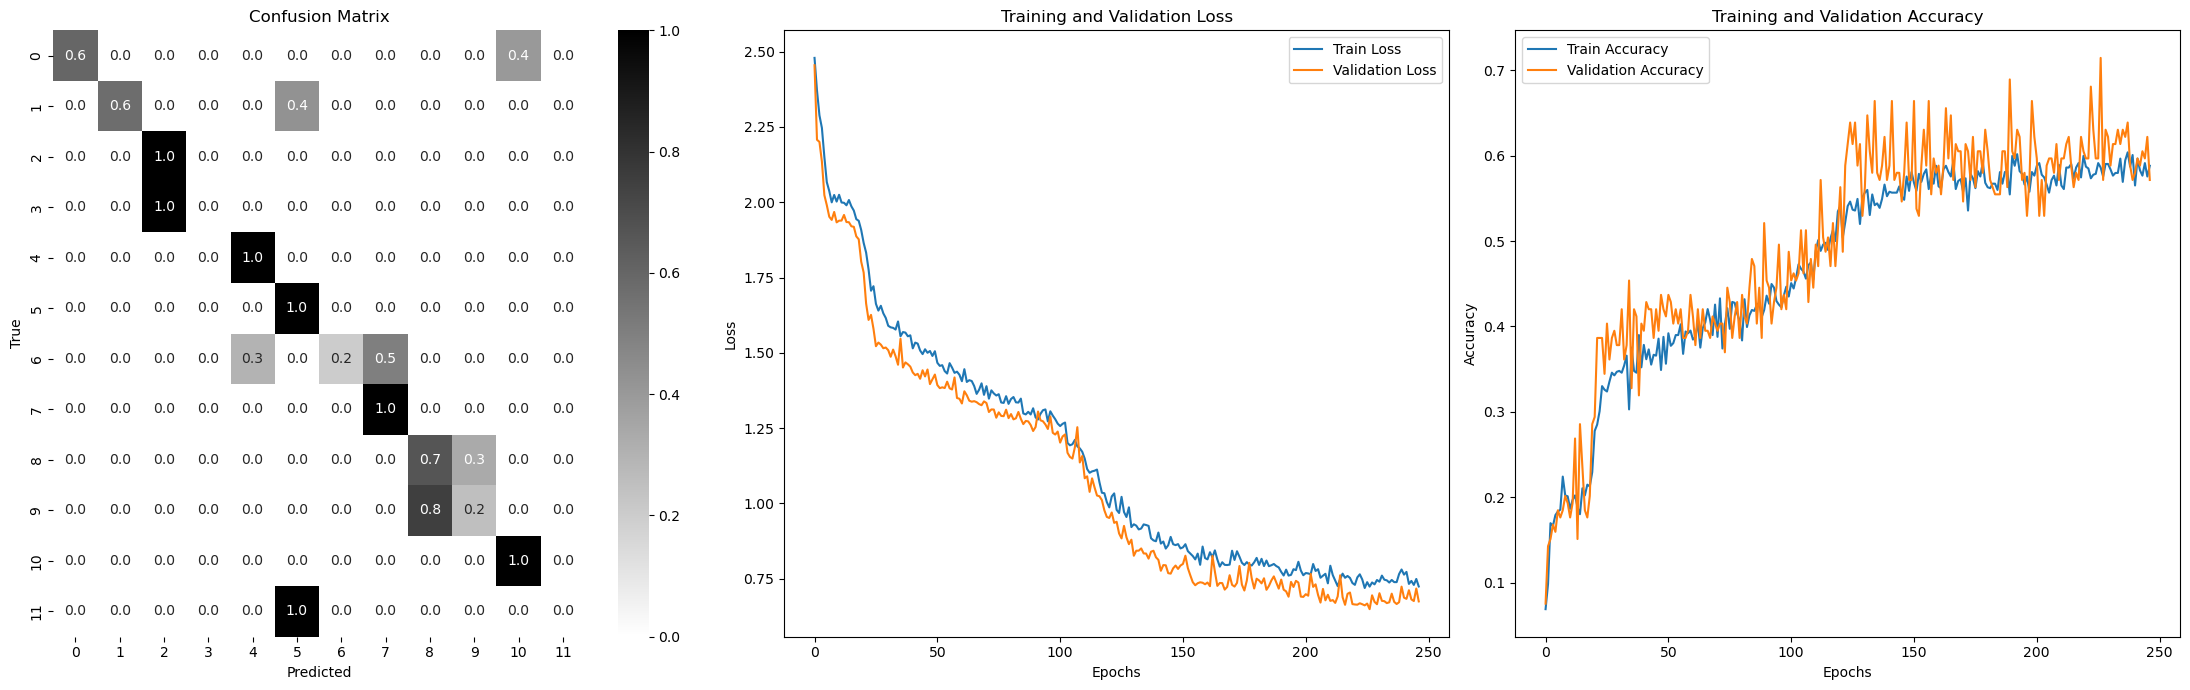

In [95]:
#----------------------------------------------
# CONFUSION MATRIX AND LOSS CURVES FOR MODEL_01
#----------------------------------------------

import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
sns.heatmap(cm3, annot=True, fmt='.1f', cmap='binary', ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

axes[1].plot(history3.history['loss'], label='Train Loss')
axes[1].plot(history3.history['val_loss'], label='Validation Loss')
axes[1].set_title('Training and Validation Loss')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()

axes[2].plot(history3.history['accuracy'], label='Train Accuracy')
axes[2].plot(history3.history['val_accuracy'], label='Validation Accuracy')
axes[2].set_title('Training and Validation Accuracy')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('Accuracy')
axes[2].legend()

plt.tight_layout()
plt.show()